<a href="https://colab.research.google.com/github/julmiha25-sys/Python/blob/main/%D0%98%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%B0%D1%8F_%D0%B1%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D1%81%D1%82%D1%8C/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_%D0%B1%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D1%81%D1%82%D0%B8_%D0%B2%D0%B5%D0%B1_%D0%B4%D0%BE%D1%81%D1%82%D1%83%D0%BF%D0%B0_%D0%BD%D0%B0_%D0%BE%D1%81%D0%BD%D0%BE%D0%B2%D0%B5_%D0%BF%D1%80%D0%BE%D0%BA%D1%81%D0%B8_%D0%BB%D0%BE%D0%B3%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Обнаружено 18 подозрительных пользователей

ПОТЕНЦИАЛЬНО ВРЕДОНОСНЫЕ ФАЙЛЫ:
user_name
Efremov      6
Unknown      5
Beresnev1    4
dtype: int64

 ПОДОЗРИТЕЛЬНЫЙ ИСХОДЯЩИЙ ТРАФИК (утечка):
            bytes_sent    url
user_name                    
Doskal       125590062   9227
Satyanova     77908591   1326
Sherbina      38474060    887
Kuvshinova    17480751   2321
Smirnova      13475015   1001
Erikalov      13247891  16484
Vilkova       11567468    755
Beresnev1      8176684   4967
Unknown        6399047  26350
PervakA        5509783    958

НАРУШЕНИЯ ПОЛИТИКИ БЕЗОПАСНОСТИ:
Series([], dtype: int64)

АНОМАЛЬНАЯ АКТИВНОСТЬ В НОЧНОЕ ВРЕМЯ:
user_name
Garbuzov       1846
GukE            665
Kravcov         607
Unknown         524
Nikitin-tr      517
PervakJ         465
Kaspersky       338
Demidova        288
Sobchenko       262
Ostrovskaya     221
dtype: int64

ДЕТАЛЬНЫЙ АНАЛИЗ ПОЛЬЗОВАТЕЛЯ: Beresnev1
Всего запросов: 4967
Исходящий трафик: 7.80 MB
Входящий трафик: 409.75 MB
Ошибки: 698

АК

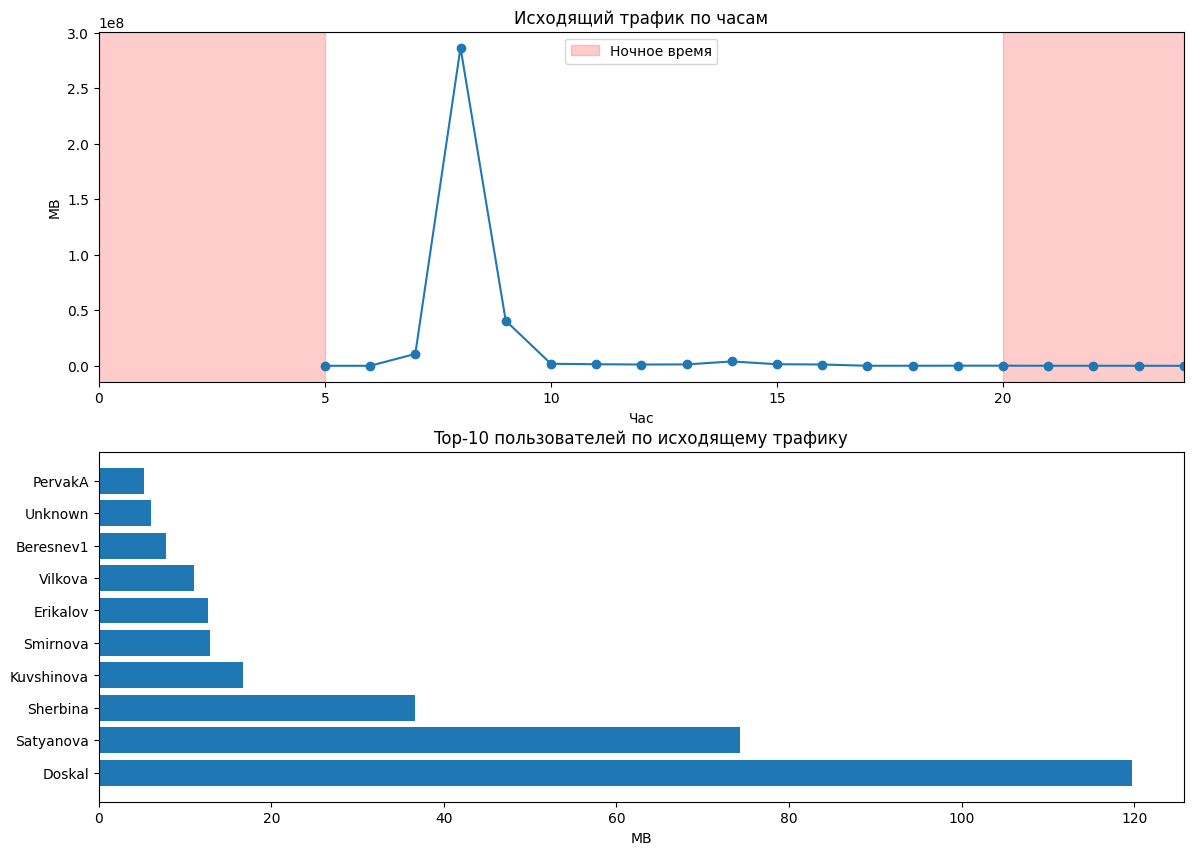

In [39]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
# Загрузка данных
df = pd.read_csv('Журнал веб-доступа 2026-03-30-2026-03-31.csv',
                 on_bad_lines='skip',
                 engine='python')
# Преобразование типов
df['datetime'] = pd.to_datetime(df['datetime'])
df['bytes_recv'] = pd.to_numeric(df['bytes_recv'], errors='coerce')
df['bytes_sent'] = pd.to_numeric(df['bytes_sent'], errors='coerce')
df['status_code'] = pd.to_numeric(df['status_code'], errors='coerce')
# Агрегация по пользователям за час
df['hour'] = df['datetime'].dt.floor('1h')
user_features = df.groupby(['user_name', 'hour']).agg({
    'url': 'count',  # количество запросов
    'bytes_sent': 'sum',  # исходящий трафик (утечка)
    'bytes_recv': 'sum',  # входящий трафик
    'status_code': lambda x: (x >= 400).sum(),  # ошибки
    'src_ip': 'nunique',  # смена IP (аномалия)
    'dst_ip': 'nunique',  # уникальные destination
    'url_categories.id': lambda x: x.nunique()  # разнообразие категорий
}).reset_index()
user_features.columns = ['user_name', 'hour', 'requests', 'bytes_sent',
                          'bytes_recv', 'errors', 'unique_ips', 'unique_dst', 'unique_categories']
# Обнаружение аномалий по пользователям
features_ml = ['requests', 'bytes_sent', 'bytes_recv', 'errors', 'unique_dst']
iso_forest = IsolationForest(contamination=0.05, random_state=42)
user_features['anomaly'] = iso_forest.fit_predict(user_features[features_ml])
user_features['anomaly'] = user_features['anomaly'].map({1: 'normal', -1: 'suspicious'})
# Анализ подозрительных пользователей
suspicious_users = user_features[user_features['anomaly'] == 'suspicious']['user_name'].unique()
print(f"Обнаружено {len(suspicious_users)} подозрительных пользователей")
# Угроза 1: Попытки загрузки вредоносных файлов
malicious_extensions = ['.exe', '.dll', '.ps1', '.bat', '.scr', '.js', '.vbs']
df['is_malicious'] = df['url'].str.lower().str.endswith(tuple(malicious_extensions))
malicious_downloads = df[df['is_malicious']].groupby('user_name').size().sort_values(ascending=False)
print("\nПОТЕНЦИАЛЬНО ВРЕДОНОСНЫЕ ФАЙЛЫ:")
print(malicious_downloads.head(10))
# Угроза 2: Утечка данных (большой исходящий трафик)
data_exfil = df.groupby('user_name').agg({
    'bytes_sent': 'sum',
    'url': 'count'
}).sort_values('bytes_sent', ascending=False).head(10)
print("\n ПОДОЗРИТЕЛЬНЫЙ ИСХОДЯЩИЙ ТРАФИК (утечка):")
print(data_exfil)
# Угроза 3: Доступ к запрещенным категориям
blocked_categories = ['Pornography', 'Gambling', 'Hacking', 'Phishing']
df['is_blocked'] = df['url_categories.id'].isin(blocked_categories)
policy_violations = df[df['is_blocked']].groupby('user_name').size().sort_values(ascending=False)
print("\nНАРУШЕНИЯ ПОЛИТИКИ БЕЗОПАСНОСТИ:")
print(policy_violations.head(10))
# Угроза 4: Аномальное время активности (ночная работа) - UG -5 GMT (c 20 до 7 ч)
df['hour_of_day'] = df['datetime'].dt.hour
night_activity = df[(df['hour_of_day'] >= 15) | (df['hour_of_day'] < 2)]
night_users = night_activity.groupby('user_name').size().sort_values(ascending=False)
print("\nАНОМАЛЬНАЯ АКТИВНОСТЬ В НОЧНОЕ ВРЕМЯ:")
print(night_users.head(10))
# Детальный анализ подозрительного пользователя
if len(suspicious_users) > 0:
    user = suspicious_users[0]
    user_logs = df[df['user_name'] == user]
    print(f"\nДЕТАЛЬНЫЙ АНАЛИЗ ПОЛЬЗОВАТЕЛЯ: {user}")
    print(f"Всего запросов: {len(user_logs)}")
    print(f"Исходящий трафик: {user_logs['bytes_sent'].sum() / 1024 / 1024:.2f} MB")
    print(f"Входящий трафик: {user_logs['bytes_recv'].sum() / 1024 / 1024:.2f} MB")
    print(f"Ошибки: {user_logs['status_code'].ge(400).sum()}")
# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
# Трафик по часам
hourly_traffic = df.groupby(df['datetime'].dt.hour+5)['bytes_sent'].sum()
axes[0].plot(hourly_traffic.index, hourly_traffic.values, marker='o')
axes[0].set_title('Исходящий трафик по часам')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('MB')
axes[0].axvspan(20, 24, alpha=0.2, color='red', label='Ночное время')
axes[0].axvspan(0, 5, alpha=0.2, color='red')
axes[0].set_xlim(0, 24)
axes[0].legend()
# Top пользователей по трафику
top_users = df.groupby('user_name')['bytes_sent'].sum().nlargest(10)
axes[1].barh(range(len(top_users)), top_users.values / 1024 / 1024)
axes[1].set_yticks(range(len(top_users)))
axes[1].set_yticklabels(top_users.index)
axes[1].set_title('Top-10 пользователей по исходящему трафику')
axes[1].set_xlabel('MB')
# Генерация алертов
alerts = []
# Алерт 1: Вредоносные файлы
if len(malicious_downloads) > 0:
    for user, count in malicious_downloads.head(5).items():
        alerts.append(f"CRITICAL: Пользователь {user} скачал {count} потенциально вредоносных файлов")
# Алерт 2: Утечка данных
high_egress = df.groupby('user_name')['bytes_sent'].sum()
for user in high_egress[high_egress > 100 * 1024 * 1024].index:  # >100 MB
    alerts.append(f"HIGH: Пользователь {user} отправил {high_egress[user]/1024/1024:.1f} MB данных")
print("\nАКТИВНЫЕ АЛЕРТЫ БЕЗОПАСНОСТИ:")
print("\n".join(alerts))